In [1]:
%load_ext autoreload
%autoreload 2

import warnings

warnings.filterwarnings("ignore")

# Performance

How memory hungry is glass box UMAP? How big of a dataset can you fit on a typical laptop? How much does using a GPU increase time to fit? These questions are answered on this page.

## How a fit works

A fit has two stages. **First**, a nearest-neighbor graph is constructed over the input array `X`, capturing which points are close to which in feature space. **Second**, a small encoder network is trained whose loss encourages the embedding to preserve those neighbor relationships in low dimensions. The graph build runs on the CPU. The encoder runs on whichever device is selected (CPU, MPS, or CUDA).

Two implementation details govern what fits and how fast it runs. Graph construction uses [`pynndescent`](https://pynndescent.readthedocs.io/), which expects the full input array in RAM (and does not stream from disk). The resulting graph is sparse and small in absolute terms (a few bytes per edge), but the working set during the build is large. Once the graph is generated, the encoder is trained by iterating over the graph's edges in batches, with the dataloader reading rows from the same in-memory `X` for every batch.

At least in principle, both stages could be out-of-core. An out-of-core nearest-neighbor library, plus a graph-aware streaming dataloader that reads rows from disk indexed by the edge list, would lift both memory ceilings substantially without changing what glass box UMAP does. We do not have that today, so the rest of this page measures the ceilings as they exist: a memory frontier set by the graph build, then a speed profile that depends on which device the encoder runs on.

## How big a dataset fits on a typical laptop?

:::{note}
The local numbers below come from a 2023 14-inch MacBook Pro with an M3 Max chip, 14 cores, 36 GB of unified memory, and the integrated GPU exposed to PyTorch through MPS. We treat that machine as a stand-in for "a typical laptop."
:::

:::{warning}
A faster GPU buys you faster training (more on that in the next section), but it does not improve the memory bottleneck associated with nearest-neighbor graph construction. The graph is built on the CPU regardless of the training device, and both the input array and the graph live in host RAM.
:::

The grid below ran the nearest-neighbor graph build on Gaussian blobs of shape `(n_samples, n_features)` for every cell. We measure peak resident set size (RSS), the total bytes the process holds in physical memory at the highest point during graph construction. The training loop adds a couple of gigabytes of model and optimizer state on top of these numbers, but nearest-neighbor graph construction is the bottleneck that decides what can be fit.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

DATA_DIR = Path("performance_data")
grid_df = pd.read_csv(DATA_DIR / "memory_grid.csv")
workers_df = pd.read_csv(DATA_DIR / "workers.csv")
workers_h100_csv = DATA_DIR / "workers_h100.csv"
workers_h100_df = pd.read_csv(workers_h100_csv) if workers_h100_csv.exists() else None
workers_t4_csv = DATA_DIR / "workers_t4.csv"
workers_t4_df = pd.read_csv(workers_t4_csv) if workers_t4_csv.exists() else None

encoder_local = pd.read_csv(DATA_DIR / "encoder_size.csv")
encoder_t4 = pd.read_csv(DATA_DIR / "encoder_size_t4.csv").assign(device="t4")
encoder_h100 = pd.read_csv(DATA_DIR / "encoder_size_h100.csv").assign(device="h100")
encoder_df = pd.concat([encoder_local, encoder_t4, encoder_h100], ignore_index=True)

sample_levels = sorted(grid_df["n_samples"].unique())
feature_levels = sorted(grid_df["n_features"].unique())

heat_ok = np.full((len(sample_levels), len(feature_levels)), np.nan, dtype=np.float64)
ok_mask = np.zeros_like(heat_ok, dtype=bool)
for _, row in grid_df.iterrows():
    i = sample_levels.index(int(row["n_samples"]))
    j = feature_levels.index(int(row["n_features"]))
    if bool(row["ok"]):
        heat_ok[i, j] = row["peak_rss_bytes"] / 1e9
        ok_mask[i, j] = True

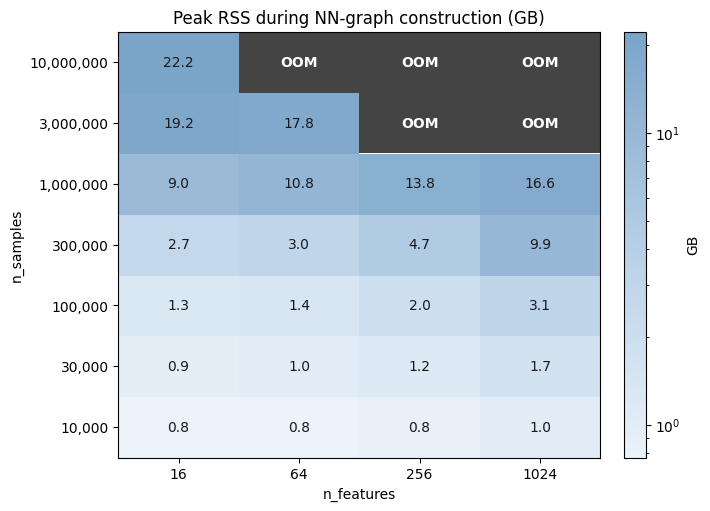

In [3]:
from matplotlib.colors import LinearSegmentedColormap

pastel_cmap = LinearSegmentedColormap.from_list(
    "pastel_blue", ["#EAF2FA", "#B6CFE6", "#7AA4C8"]
)

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
im = ax.imshow(
    heat_ok,
    origin="lower",
    cmap=pastel_cmap,
    norm=LogNorm(vmin=float(np.nanmin(heat_ok)), vmax=float(np.nanmax(heat_ok))),
    aspect="auto",
)
for i in range(len(sample_levels)):
    for j in range(len(feature_levels)):
        if ok_mask[i, j]:
            val = heat_ok[i, j]
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", color="#1a1a1a", fontsize=10)
        else:
            ax.add_patch(
                plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor="#444444", edgecolor="none")
            )
            ax.text(j, i, "OOM", ha="center", va="center", color="white", fontsize=10, fontweight="bold")
ax.set_xticks(range(len(feature_levels)))
ax.set_xticklabels(feature_levels)
ax.set_yticks(range(len(sample_levels)))
ax.set_yticklabels([f"{n:,}" for n in sample_levels])
ax.set_xlabel("n_features")
ax.set_ylabel("n_samples")
ax.set_title("Peak RSS during NN-graph construction (GB)")
fig.colorbar(im, ax=ax, label="GB")
plt.show()

Cells in the top-right corner, where `n_samples` and `n_features` are both large, hit the out of memory (OOM) zone. Everything else shows the peak RSS the cell actually used. Read off the boundary to size your fits: roughly fifteen million points at 16 features, three million at 64, one million at 1024, and a hundred thousand at any feature count up to a thousand without breaking a sweat. Going beyond either edge needs more RAM or a different strategy.

The shape of the surface is also informative. Memory grows much more steeply along `n_samples` than along `n_features`, so doubling the number of observations is a much bigger ask of the machine than doubling the number of features.

If your dataset is too large to construct the graph, the most obvious but potentially least practical solution is to use a machine with more RAM. If that's not possible, you could consider either projecting to fewer features before the nearest-neighbor step (see [PCA preprocessing](pca_preprocessing.ipynb)), or fit on a representative subsample and `transform` the rest, since glass box UMAP is parametric. Neither changes the underlying ceiling, but both can move you well inside it.

## Speeding up training

The dominant cost knob in glass box UMAP is `epochs`. The encoder is a neural network that needs enough training time to actually settle on a good embedding, so reducing the epoch budget is the most direct way to make a fit take less time. Many problems converge well before the default 200-epoch budget, and you can often cut that in half or further without a measurable change in the embedding. See [monitoring training](monitoring_training.ipynb) for how to watch the loss curve and decide when to stop.

Reducing `epochs` makes a fit shorter by training on fewer examples. The rest of this section is about a different lever: making each epoch run faster. Two knobs control that, the device the encoder runs on and the number of subprocesses the dataloader spawns. The next two subsections measure each in turn.

### Picking a device

When picking hardware for a fit, the practical question is how much faster a GPU makes things compared to plain CPU. To answer it, we ran the same one-epoch fit on full MNIST (70k observations, 784 features) across four devices: the laptop's CPU and MPS, plus a Modal T4 and an H100. Each device runs with its near-optimal `num_workers` (2 for CPU and MPS, 8 for T4 and H100), the default `batch_size=10000`, and the default encoder (133K parameters). The next subsection covers `num_workers` directly, but for now treat those values as a given. The chart below is the result.

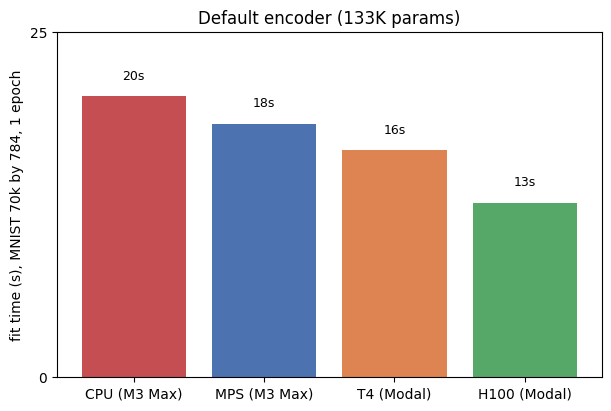

In [4]:
device_styles = {
    "cpu":  ("CPU (M3 Max)",  "#c44e52"),
    "mps":  ("MPS (M3 Max)",  "#4c72b0"),
    "t4":   ("T4 (Modal)",    "#dd8452"),
    "h100": ("H100 (Modal)",  "#55a868"),
}
device_order = ["cpu", "mps", "t4", "h100"]

default_df = encoder_df[encoder_df["encoder"] == "133K"].set_index("device").reindex(device_order)

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
labels = [device_styles[d][0] for d in device_order]
colors = [device_styles[d][1] for d in device_order]
ax.bar(labels, default_df["fit_time_s"].values, color=colors)

for i, v in enumerate(default_df["fit_time_s"].values):
    ax.text(i, v + 1.0, f"{v:.0f}s", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("fit time (s), MNIST 70k by 784, 1 epoch")
ax.set_title("Default encoder (133K params)")

y_top = float(np.ceil(default_df["fit_time_s"].max() / 25.0)) * 25.0
ax.set_ylim(0, y_top)
ax.set_yticks(np.arange(0, y_top + 1, 25))
ax.grid(True, axis="y", ls=":", alpha=0.4)
plt.show()

Picking up a GPU does help, but only modestly. CPU is the slowest at about 20 seconds. MPS shaves a couple of seconds off, T4 a bit more, and H100 the most, dropping to about 13 seconds. The improvement is appreciable, however it's surprising that it falls well short of what neural-network training usually delivers when you graduate to a GPU. A factor of ten or more is typical when a real model moves onto a discrete card. Here even the H100 is only about 1.6x faster than CPU, and the cheap T4 lands within a few seconds of the H100, which makes the price difference hard to justify on this workload.

The reason is that the encoder is small at 133K parameters, so per-step time is dominated by CPU-bound bookkeeping (DataLoader iteration, Lightning callbacks, the optimizer step, the trainer thread) rather than by GPU compute. As evidence, we re-ran the same fit with progressively larger encoders, widening `hidden_size` and deepening `n_hidden_layers` to reach 463K, 2M, 5M, and 18M parameters. If the GPU were already the bottleneck, all four devices should slow down by roughly the same factor as the model grows. They do not.

:::{warning}
A larger encoder is not a better one. The bigger models in the next plot exist only to characterize how each device scales with model compute. For real fits, choose the encoder that matches your data. On simple manifolds, a smaller network can produce a cleaner embedding, as the [embedding refinement](embedding_refinement.ipynb) walkthrough shows on the 3-feature Swiss roll.
:::

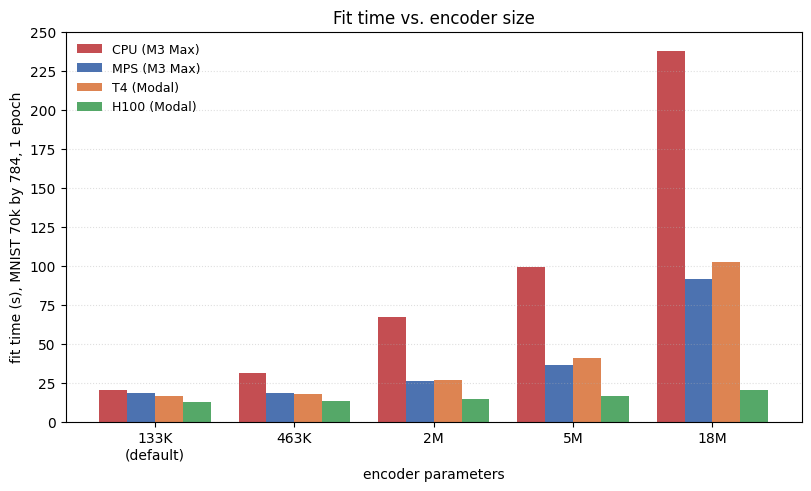

In [5]:
device_styles = {
    "cpu":  ("CPU (M3 Max)",  "#c44e52"),
    "mps":  ("MPS (M3 Max)",  "#4c72b0"),
    "t4":   ("T4 (Modal)",    "#dd8452"),
    "h100": ("H100 (Modal)",  "#55a868"),
}

size_order = ["133K", "463K", "2M", "5M", "18M"]
device_order = ["cpu", "mps", "t4", "h100"]

x = np.arange(len(size_order))
n_devices = len(device_order)
bar_width = 0.8 / n_devices

fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
for i, dev_key in enumerate(device_order):
    label, color = device_styles[dev_key]
    sub = encoder_df[encoder_df["device"] == dev_key].set_index("encoder").reindex(size_order)
    offset = (i - (n_devices - 1) / 2) * bar_width
    ax.bar(x + offset, sub["fit_time_s"].values, bar_width, color=color, label=label)

ax.set_xticks(x)
ax.set_xticklabels(["133K\n(default)" if s == "133K" else s for s in size_order])
ax.set_xlabel("encoder parameters")
ax.set_ylabel("fit time (s), MNIST 70k by 784, 1 epoch")
ax.set_title("Fit time vs. encoder size")

y_top = float(np.ceil(encoder_df["fit_time_s"].max() / 25.0)) * 25.0
ax.set_ylim(0, y_top)
ax.set_yticks(np.arange(0, y_top + 1, 25))
ax.grid(True, axis="y", ls=":", alpha=0.4)
ax.legend(frameon=False, fontsize=9)
plt.show()

As the encoder grows from 133K to 18M parameters (a 138x increase), fit time grows several-fold on CPU, T4, and MPS, but barely changes on H100, indicative of under-utilization. At the default size, every device pays roughly the same fixed overhead and the four bars are close together. As the encoder grows, the bar that grows least is the one with the most spare compute, aka the most powerful GPU tested (H100).

Ultimately, the takeaway is this: For typical glass box UMAP work where the encoder is modestly sized, CPU is enough. And when performance matters, modest speedup can be squeezed out by using a GPU.

### Number of data workers

Besides picking a device, the only knob you can turn from one fit to the next is `num_workers`, the number of Python subprocesses the dataloader spawns to pre-stage batches. The setting matters because the encoder is fast: with too few workers, batches arrive too slowly to keep it busy and the device sits idle. With too many workers, you pay scheduling overhead for nothing. The optimum depends on the device, and getting it wrong leaves a multiplicative factor of throughput on the table.

The plot below sweeps `num_workers` from zero through twelve on full MNIST (70k observations, 784 features) for one training epoch on each of CPU, MPS, T4, and H100.

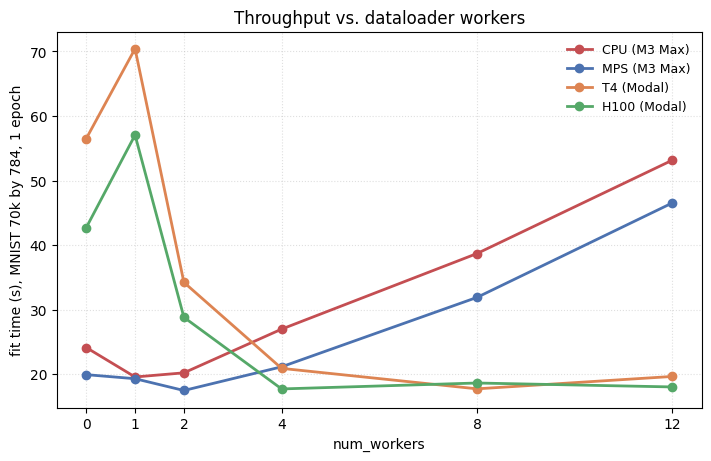

In [6]:
cpu_df = workers_df[workers_df["device"] == "cpu"].sort_values("num_workers")
mps_df = workers_df[workers_df["device"] == "mps"].sort_values("num_workers")

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.plot(cpu_df["num_workers"], cpu_df["fit_time_s"], "o-", color="#c44e52", label="CPU (M3 Max)", lw=2)
ax.plot(mps_df["num_workers"], mps_df["fit_time_s"], "o-", color="#4c72b0", label="MPS (M3 Max)", lw=2)
if workers_t4_df is not None:
    t4_df = workers_t4_df.sort_values("num_workers")
    ax.plot(t4_df["num_workers"], t4_df["fit_time_s"], "o-", color="#dd8452", label="T4 (Modal)", lw=2)
if workers_h100_df is not None:
    h_df = workers_h100_df.sort_values("num_workers")
    ax.plot(h_df["num_workers"], h_df["fit_time_s"], "o-", color="#55a868", label="H100 (Modal)", lw=2)
ax.set_xlabel("num_workers")
ax.set_ylabel("fit time (s), MNIST 70k by 784, 1 epoch")
ax.set_title("Throughput vs. dataloader workers")
ax.set_xticks(sorted({int(x) for x in workers_df["num_workers"]}))
ax.grid(True, ls=":", alpha=0.4)
ax.legend(frameon=False, fontsize=9)
plt.show()

The four lines tell different stories. The two laptop devices (CPU and MPS) sit close together throughout. They do best at 1-2 workers, then climbs steeply as more workers presumably oversubscribe the laptop's 14 cores.

The two discrete GPUs need more workers to feed them. T4 and H100 both look very slow at 0-1 workers, where the dataloader cannot keep up with the device, then drop sharply between 2-4 workers and flatten by 8. Their hosts have more cores (8 on T4, 32 on H100), so adding workers does not oversubscribe in the same range the laptop does.

---

:::{admonition} Looking to reproduce these results?
:class: note

See [this README](https://github.com/Arcadia-Science/glass-box-umap/blob/main/docs/user_guide/performance_data/README.md) for the scripts and commands.
:::